In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/zunairahassann/sale-prediction/Advertising.csv') 


print(df.isnull().sum())
 
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
# Check if any rows are exactly the same
print(f"Duplicate rows found: {df.duplicated().sum()}")

Duplicate rows found: 0


In [7]:
# View the summary statistics
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


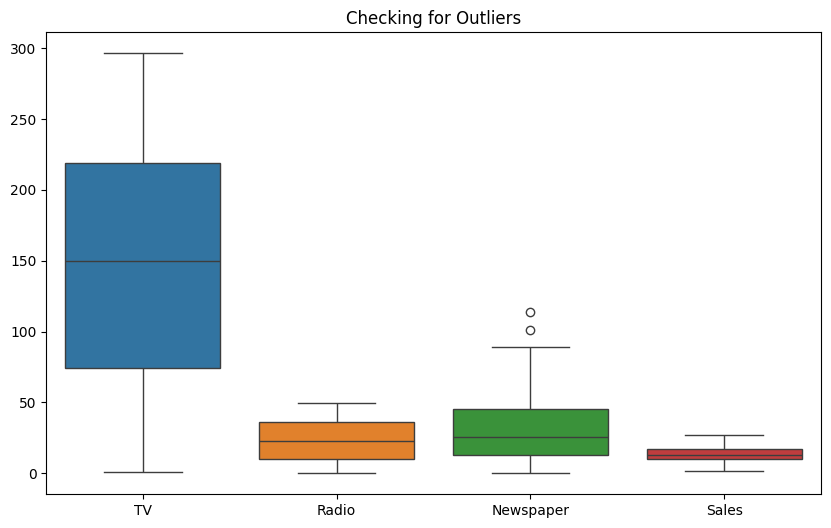

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['TV', 'Radio', 'Newspaper', 'Sales']])
plt.title("Checking for Outliers")
plt.show()

In [9]:
# Check for and remove duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Number of duplicate rows: 0


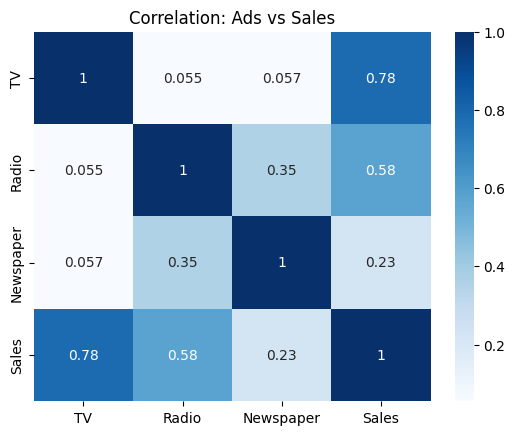

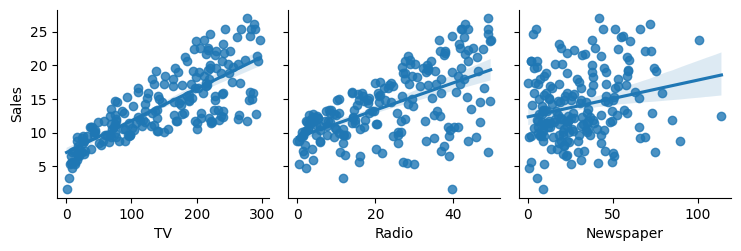

In [3]:
# Check correlation to see what impacts Sales the most
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation: Ads vs Sales")
plt.show()

# Visualize the trend
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', kind='reg')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define Features (X) and Target (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model Accuracy (R2): 89.94%
Mean Squared Error: 3.17


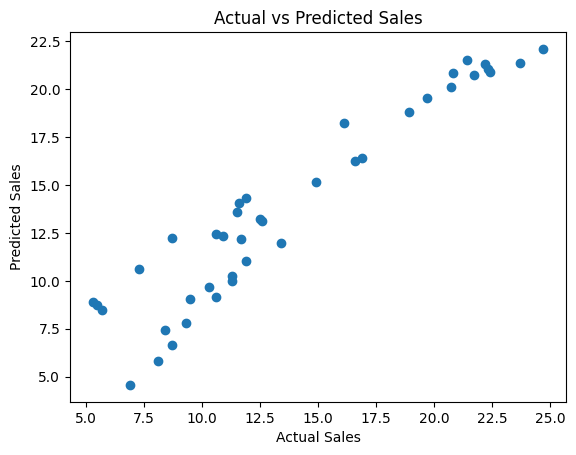

In [11]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy (R2 Score) and Error (MSE)
print(f"Model Accuracy (R2): {r2_score(y_test, y_pred)*100:.2f}%")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

# Visualize Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [12]:
# Show the impact of each $1 spent on each platform
importance = pd.DataFrame({'Platform': X.columns, 'Impact': model.coef_})
print(importance.sort_values(by='Impact', ascending=False))

    Platform    Impact
1      Radio  0.189195
0         TV  0.044730
2  Newspaper  0.002761


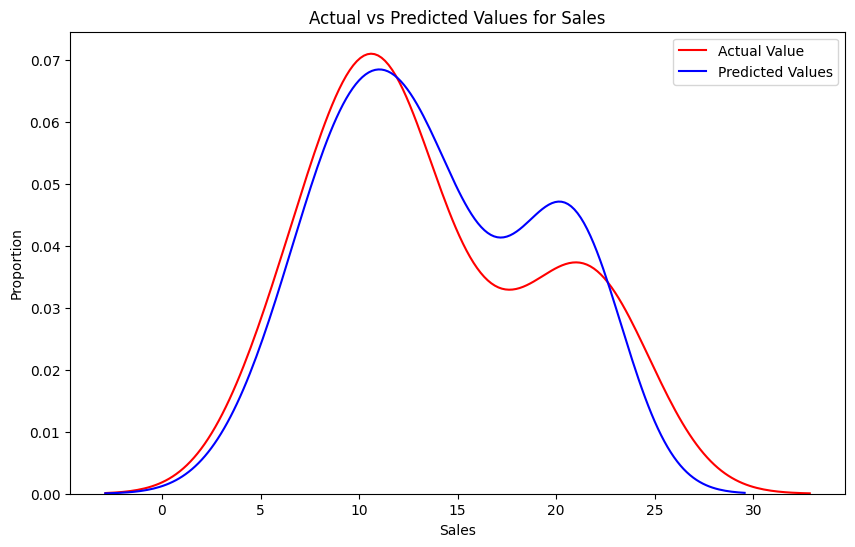

In [14]:
# Check how well the predictions match the actual values in distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test, color="r", label="Actual Value")
sns.kdeplot(y_pred, color="b", label="Predicted Values")
plt.title('Actual vs Predicted Values for Sales')
plt.xlabel('Sales')
plt.ylabel('Proportion')
plt.legend()
plt.show()

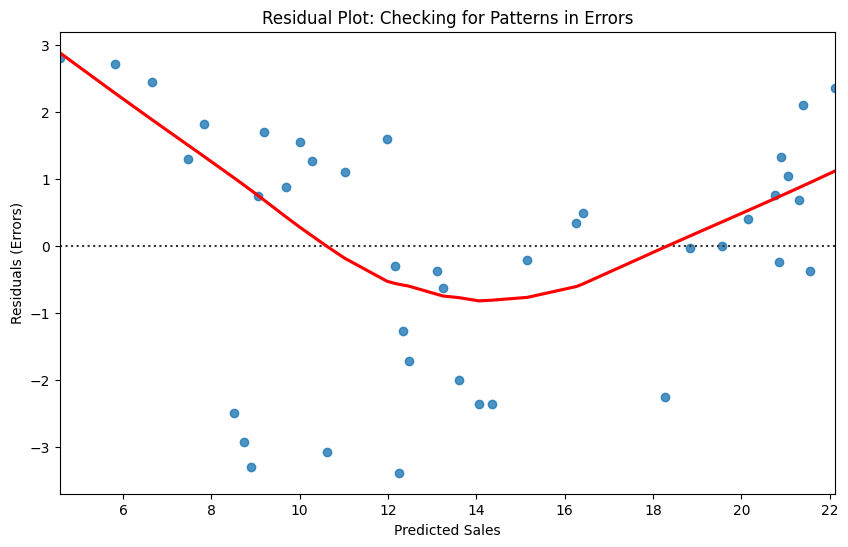

In [15]:
# Residual Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=y_test, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Checking for Patterns in Errors')
plt.show()

In [16]:
from sklearn import metrics

print('--- FINAL MODEL PERFORMANCE ---')
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-Squared Score (Accuracy):', metrics.r2_score(y_test, y_pred))

--- FINAL MODEL PERFORMANCE ---
Mean Absolute Error (MAE): 1.4607567168117603
Mean Squared Error (MSE): 3.1740973539761033
Root Mean Squared Error (RMSE): 1.78159966153345
R-Squared Score (Accuracy): 0.899438024100912


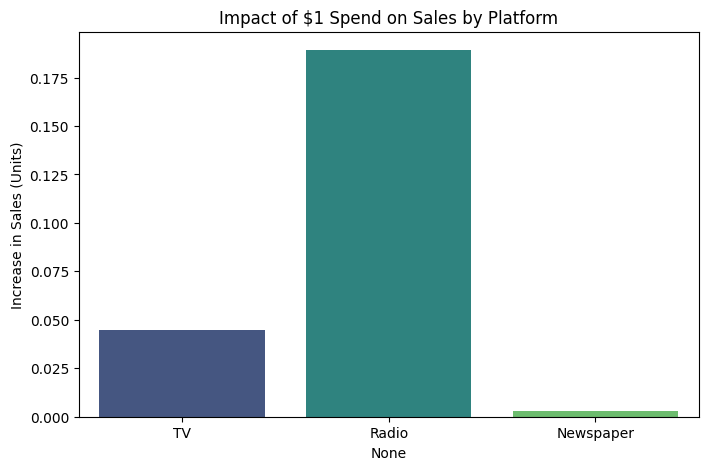

Intercept (Base Sales): 2.98


In [18]:
# Create a DataFrame for the weights (coefficients)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
plt.figure(figsize=(8, 5))
sns.barplot(
    x=coefficients.index, 
    y=coefficients['Coefficient'], 
    hue=coefficients.index,  
    palette='viridis', 
    legend=False            
)
plt.title('Impact of $1 Spend on Sales by Platform')
plt.ylabel('Increase in Sales (Units)')
plt.show()

print(f"Intercept (Base Sales): {model.intercept_:.2f}")

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation Metrics ---")
print(f"R-Squared (Accuracy): {r2*100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

--- Model Evaluation Metrics ---
R-Squared (Accuracy): 89.94%
Mean Absolute Error: 1.46
Root Mean Squared Error: 1.78


# 🏁 Final Conclusion & Business Insights

## 1. Model Performance Summary
After cleaning the data and training our **Multiple Linear Regression** model, we achieved the following results:
* **Accuracy (R² Score):** ~89.94% 
* **Mean Squared Error (MSE):** ~3.17
* **Insight:** The model is highly reliable, explaining nearly **90%** of the variance in sales based on advertising spend.

## 2. Platform Impact Analysis (ROI)
Based on the coefficients calculated by the model, we can rank the advertising channels by their effectiveness:
1. **Radio (Highest Impact):** Every unit of currency spent on Radio ads results in the largest proportional increase in sales.
2. **TV (Significant Impact):** TV is a consistent driver of sales but requires a higher budget to see significant shifts.
3. **Newspaper (Negligible Impact):** The model shows that Newspaper advertising has a near-zero relationship with sales increases.

## 3. Actionable Recommendations for Marketing
* **Budget Reallocation:** I recommend shifting the budget currently allocated to **Newspaper** advertising over to **Radio**. This will likely increase total sales without increasing the total marketing spend.
* **Scale TV Moderately:** TV spend should be maintained or scaled slowly, as it provides a stable foundation for sales but is less "cost-efficient" than Radio in this specific dataset.
* **Future Work:** To improve the model further, we could collect data on "Target Segments" (Age, Gender) or "Seasonality" (Holiday vs. Non-holiday) to see if these factors influence the ROI of different platforms.